## Submission 2. Bias

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
from scipy import stats
import starbars

cmap = mpl.colormaps['cool']

In [7]:
from spyglass.shijiegu.behavior import get_transition_matrix_animal, return_neighbor_nonneighor
from spyglass.shijiegu.changeOfMind_byTransition import find_COM_transitions, info2matrix

from spyglass.shijiegu.Analysis_SGU import ChangeofMind
from spyglass.common.common_position import IntervalPositionInfo, RawPosition, IntervalLinearizedPosition

In [29]:
list_of_days_animals = {}
seq_animals = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']
seq_animals[animal] = 'rev2'

### Bias

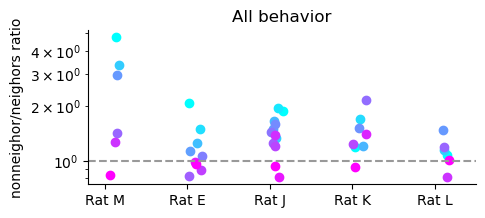

In [30]:
fig, axes = plt.subplots(1, 1, figsize=(5, 2),sharey = True)

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]
for animal in animals:

    days = list_of_days_animals[animal]
    T = get_transition_matrix_animal(animal, animal, list_of_days_animals[animal])
    P_behavior = np.stack([T[d] for d in T], axis = 2)
    P_neighors, P_nonneighors = return_neighbor_nonneighor(P_behavior)

    norm = Normalize(vmin=0, vmax=len(days)-1)
    
    for ind in np.arange(len(days)):
        ratio = P_nonneighors[ind]/P_neighors[ind]
        x_shift = np.random.rand(1)/5
        axes.scatter(np.zeros_like(ratio) + animal_ind + x_shift, ratio, color = cmap(norm(ind)))

    animal_ind += 1

# log scale
axes.set_yscale('log')

axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
axes.set_xticks(np.arange(len(animals)));
axes.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
axes.set_xlim([-0.2,len(animals)-0.5]);
axes.set_title("All behavior")
axes.set_ylabel("nonneighor/neighors ratio")
axes.spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1_bias.pdf"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png",bbox_inches='tight')

### Stats for bias

In [31]:
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}
import statsmodels.api as sm
import numpy.matlib as ml
import matplotlib.patheffects as PathEffects

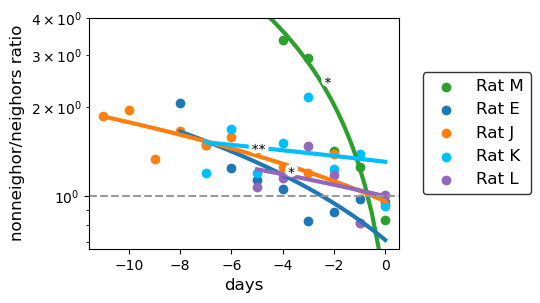

In [32]:
fig, axes = plt.subplots(1, 1, figsize=(4, 3))

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]
for animal in animals:

    days = list_of_days_animals[animal]
    T = get_transition_matrix_animal(animal, animal, list_of_days_animals[animal])
    P_behavior = np.stack([T[d] for d in T], axis = 2)
    P_neighors, P_nonneighors = return_neighbor_nonneighor(P_behavior)

    norm = Normalize(vmin=0, vmax=len(days)-1)

    ratios = [P_nonneighors[ind]/P_neighors[ind] for ind in np.arange(len(days))]
        
    x_indeces = np.arange(len(days))
    axes.scatter(x_indeces - x_indeces[-1], ratios,
                 color = color_by_rat[animal.lower()[:5]], label = f"Rat {animal[0].upper()}")
    #axes.plot(x_indeces - x_indeces[-1], ratios, color = color_by_rat[animal.lower()[:5]])
    X = sm.add_constant(x_indeces)

    # 3. Create and fit the OLS (Ordinary Least Squares) model
    model = sm.OLS(ratios, X)
    results = model.fit()

    X_pred = np.linspace(x_indeces[0],x_indeces[-1],20)
    X_pred = sm.add_constant(X_pred)
    X_plot = X_pred[:,-1] - x_indeces[-1]
    Y_pred = results.predict(X_pred)
    axes.plot(X_plot, Y_pred, color=color_by_rat[animal.lower()[:5]], linewidth = 3)
    pvalue = results.pvalues[1]
    mid_ind = int(len(X_plot)/2)
    if pvalue <= 0.001:
        txt = axes.text(X_plot[mid_ind], Y_pred[mid_ind], "**", color = 'k')
    elif pvalue <= 0.01:
        txt = axes.text(X_plot[mid_ind], Y_pred[mid_ind], "*", color = 'k')
    txt.set_path_effects([PathEffects.withStroke(linewidth=5, foreground='w')])


    #### add stats
    # t_statistic, p_value = stats.ttest_rel(P_neighors, P_nonneighors)
    # print("p_value",p_value)
    # axes.text(animal_ind + 0.1,5,str(np.round(p_value, 4)))
    ########

    animal_ind += 1

# log scale
axes.set_yscale('log')
legend = axes.legend(edgecolor = 'k',fontsize = 12, loc='upper left',bbox_to_anchor=(1.05, 0.8))
# Get the legend frame (which is a Rectangle object)
frame = legend.get_frame()
# Set the linewidth of the legend frame
frame.set_linewidth(1)


axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
#axes.set_xticks(np.arange(len(animals)));
#axes.set_xticklabels(["Rat " + animal[0] for animal in animals]);
#axes.set_xlim([-1,len(animals) + 1]);
axes.set_ylim([1/1.5,4]);
#axes.set_title("All behavior")
axes.set_ylabel("nonneighor/neighors ratio", fontsize = 12)
axes.set_xlabel("days", fontsize = 12)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1_bias_linear_regression"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png")

### More stats for bias: Mixed linear model

In [33]:
GLM_x = []
GLM_y = []

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]
for animal in animals:

    days = list_of_days_animals[animal]
    T = get_transition_matrix_animal(animal, animal, list_of_days_animals[animal])
    P_behavior = np.stack([T[d] for d in T], axis = 2)
    P_neighors, P_nonneighors = return_neighbor_nonneighor(P_behavior)

    norm = Normalize(vmin=0, vmax=len(days)-1)

    ratios = [P_nonneighors[ind]/P_neighors[ind] for ind in np.arange(len(days))]
        
    x_indeces = np.arange(len(days))

    animal_category = np.array([a == animal for a in animals]).reshape((1,-1))
    X = x_indeces #- x_indeces[-1]
    X = X.reshape((-1,1))

    Y = np.array(ratios).reshape((-1,1))

    X_animal_category = ml.repmat(animal_category, np.shape(X)[0], 1)
    X = np.hstack((X_animal_category, X))
    GLM_x.append(X)
    GLM_y.append(Y)

GLM_x = np.vstack(GLM_x)
GLM_y = np.vstack(GLM_y)

In [34]:
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_x[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["day"] = GLM_x[:,len(animals)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = np.log(GLM_y)

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()
print("p value of days:",ols_result1.pvalues[-1])

print("Mixed Linear Effect \n",ols_result1.summary())

p value of days: 2.1092088306873462e-05
Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     9.008
Date:                Thu, 01 Jan 2026   Prob (F-statistic):           1.42e-05
Time:                        12:55:01   Log-Likelihood:                -1.2635
No. Observations:                  41   AIC:                             14.53
Df Residuals:                      35   BIC:                             24.81
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

/tmp/ipykernel_243600/91038292.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("p value of days:",ols_result1.pvalues[-1])


In [35]:
np.exp(-0.0792)

0.9238551349397642